<a href="https://colab.research.google.com/github/Dhananjay07-ai/Dhananjay-Saxena/blob/main/PlantDiseasePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
!pip install opendatasets

In [48]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/emmarex/plantdisease")

Skipping, found downloaded files in "./plantdisease" (use force=True to force download)


In [49]:
import pandas as pd
data = pd.read_csv('/content/plantdisease/plant_disease_text_dataset.csv')

In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
# Remove duplicates
data = data.drop_duplicates()

# Drop missing rows
data = data.dropna()

In [52]:
import pandas as pd

data = pd.read_csv('/content/plantdisease/plant_disease_text_dataset.csv')

# Show basic info
print("Shape:", data.shape)
print("\nColumns in dataset:\n", data.columns.tolist())
print("\nFirst few rows:\n")
print(data.head())

Shape: (117, 4)

Columns in dataset:
 ['Plant', 'Disease', 'Symptoms', 'Treatment']

First few rows:

    Plant       Disease                                           Symptoms  \
0  Tomato   Late Blight  Water-soaked brown spots on leaves and fruit, ...   
1  Tomato  Early Blight  Dark brown concentric spots on lower leaves, y...   
2  Tomato     Leaf Curl  Upward curling leaves, yellowing and stunted g...   
3  Potato   Late Blight  Dark lesions on leaves and stems, white fungal...   
4  Potato   Black Scurf  Black sclerotia on tuber surface, poor sprouting.   

                                           Treatment  
0  Remove infected leaves, avoid overhead irrigat...  
1  Remove affected leaves, rotate crops, use Manc...  
2  Control whiteflies, use resistant varieties, r...  
3  Apply fungicides like Metalaxyl, ensure good d...  
4  Treat tubers before planting, rotate with non-...  


In [53]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download stopwords once
nltk.download('stopwords')

# Initialize stemmer and stopwords
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# ---------- Step 1: Identify the text column ----------
print("Available columns:", data.columns.tolist())

# Try common names or detect first object column
possible_names = ['text', 'description', 'sentence', 'comment', 'notes', 'disease', 'symptom']
text_col = None

for name in possible_names:
    if name in data.columns:
        text_col = name
        break

if text_col is None:
    text_col = data.select_dtypes(include=['object']).columns[0]
    print(f"No common text column found. Using: '{text_col}'")
else:
    print(f"Using detected text column: '{text_col}'")

# ---------- Step 2: Clean text ----------
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['clean_text'] = data[text_col].apply(clean_text)

# ---------- Step 3: Remove stopwords + apply stemming ----------
def preprocess_text(text):
    words = [stemmer.stem(word) for word in text.split() if word not in stop_words]
    return ' '.join(words)

data['processed_text'] = data['clean_text'].apply(preprocess_text)

# ---------- Step 4: Check the result ----------
print("\nSample after preprocessing:")
print(data[['clean_text', 'processed_text']].head())



Available columns: ['Plant', 'Disease', 'Symptoms', 'Treatment']
No common text column found. Using: 'Plant'

Sample after preprocessing:
  clean_text processed_text
0     tomato         tomato
1     tomato         tomato
2     tomato         tomato
3     potato         potato
4     potato         potato


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [54]:
import tensorflow as tf

dataset_path = "/content/plantdisease/PlantVillage"

# Load dataset
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),
    batch_size=32,
    label_mode='int',
    shuffle=True
)

# Save class names BEFORE mapping
class_names = dataset.class_names

# Normalize pixel values
dataset = dataset.map(lambda x, y: (x / 255.0, y))

print(" Dataset loaded successfully!")
print("Classes:", class_names)

Found 20638 files belonging to 15 classes.
 Dataset loaded successfully!
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [55]:
train_size = 0.8
val_size = 0.1
test_size = 0.1

total_batches = tf.data.experimental.cardinality(dataset).numpy()

train_ds = dataset.take(int(total_batches * train_size))
val_ds = dataset.skip(int(total_batches * train_size)).take(int(total_batches * val_size))
test_ds = dataset.skip(int(total_batches * (train_size + val_size)))

print(f"Train batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Test batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

Train batches: 516
Validation batches: 64
Test batches: 65


In [56]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

In [57]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [58]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,895 (42.61 MB)

 Trainable params: 11,170,895 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
import numpy as np

In [60]:
model = MobileNetV2(weights='imagenet')

In [61]:
import tensorflow as tf

# Load training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "plantdisease/PlantVillage",   # path to your dataset folder
    image_size=(224, 224),
    batch_size=32
)

# Optional: Split dataset
val_ds = train_ds.take(20)
train_ds = train_ds.skip(20)

# Normalize images
train_ds = train_ds.map(lambda x, y: (x/255.0, y))
val_ds = val_ds.map(lambda x, y: (x/255.0, y))

Found 20638 files belonging to 15 classes.


In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Step 1: Load dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "plantdisease/PlantVillage",
    image_size=(224, 224),
    batch_size=32
)

# Save class names before mapping
class_names = train_ds.class_names
num_classes = len(class_names)
print("Number of classes:", num_classes)
print("Classes:", class_names)

# Step 2: Normalize images
train_ds = train_ds.map(lambda x, y: (x / 255.0, y))

# Step 3: Import pre-trained MobileNetV2 (feature extractor)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,       # Remove final classification layers
    weights='imagenet'       # Use pre-trained weights
)
base_model.trainable = False  # Freeze base model

# Step 4: Build your model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Step 5: Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 6: Train
model.fit(train_ds, epochs=15)

# Step 7 (Optional): Save model
model.save("mobilenetv2_plant_disease.h5")

Found 20638 files belonging to 15 classes.
Number of classes: 15
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
645/645 ━━━━━━━━━━━━━━━━━━━━ 971s 1s/step - accuracy: 0.6757 - loss: 1.0482
Epoch 2/15
645/645 ━━━━━━━━━━━━━━━━━━━━ 936s 1s/step - accuracy: 0.8645 - loss: 0.4060
Epoch 3/15
645/645 ━━━━━━━━━━━━━━━━━━━━ 939s 1s/step - accuracy: 0.8930 - loss: 0.3193
Epoch 4/15
645/645 ━━━━━━━━━━━━━━━━━━━━ 929s 1s/step - accuracy: 0.9109 - loss: 0.2557
Epoch 5/15
645/645 ━━━━━━━━━━━━━━━━━━━━ 910s 1s/step - accuracy: 0.9204 - loss: 0.2355
Epoch 6/15
645/645 ━━━━━━━━━━━━━━━

Found 20638 files belonging to 15 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted class probabilities for the first image: [6.49250011e-12 7.75825071e-10 3.74650479e-13 4.05808942e-10
 5.68022105e-12 9.99588668e-01 3.15250873e-06 6.89709345e-10
 1.21320742e-09 9.20671300e-06 8.95024854e-08 3.98924749e-04
 3.60581143e-09 7.28833565e-15 1.41976155e-08]
Predicted class for the first image: Tomato_Bacterial_spot
True label for the first image: Tomato_Bacterial_spot


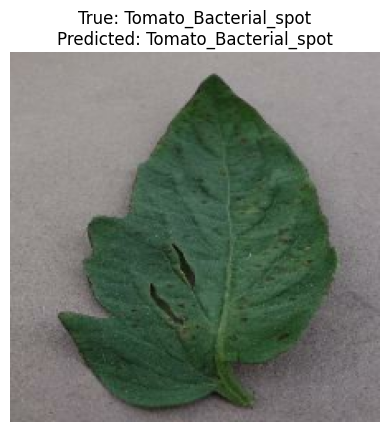

In [19]:
from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf # Added this import to the top

# Load the saved model
model = load_model('mobilenetv2_plant_disease.h5')

# Get a sample image from the test dataset
# Note: test_ds was defined in an earlier cell, but it was skipped due to KeyboardInterrupt in the last cell.
# I'll create a new test_ds for this example.

# Re-loading dataset to get test_ds
dataset_path = "/content/plantdisease/PlantVillage"
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),
    batch_size=32,
    label_mode='int',
    shuffle=True
)

train_size = 0.8
val_size = 0.1
total_batches = tf.data.experimental.cardinality(dataset).numpy()

test_ds = dataset.skip(int(total_batches * (train_size + val_size)))

# Normalize the test dataset
test_ds = test_ds.map(lambda x, y: (x / 255.0, y))

# Take one batch from the test set
for images, labels in test_ds.take(1):
    sample_images = images.numpy()
    sample_labels = labels.numpy()
    break

# Make predictions
preds = model.predict(sample_images)

# Display predictions for the first image in the batch
print(f"Predicted class probabilities for the first image: {preds[0]}")
predicted_class_index = np.argmax(preds[0])
predicted_class_name = class_names[predicted_class_index]
print(f"Predicted class for the first image: {predicted_class_name}")
print(f"True label for the first image: {class_names[sample_labels[0]]}")

# Optional: Display the first sample image
plt.imshow(sample_images[0])
plt.title(f"True: {class_names[sample_labels[0]]}\nPredicted: {predicted_class_name}")
plt.axis('off')
plt.show()

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification

#This tokenizer:
#Converts sentences to tokens
#Converts tokens to IDs
#Adds special tokens: [CLS], [SEP]
#Pads / truncates sequences
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

#Loads the pretrained BERT-base model
#---Adds a classification head on top
#---num_labels = num_classes
#Meaning:
#If you have 5 classes → output layer has 5 neurons
#If you have 38 plant disease classes → BERT outputs 38 probabilities
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_classes)

#Prints how many classification labels your BERT model is set for
print(f"BERT model initialized with {num_classes} labels.")

In [21]:
from sklearn.model_selection import train_test_split

# For disease classification, we use the 'Disease' column as both the text features and to derive the labels.
# Note: 'clean_text' was derived from the 'Plant' column, which might not be suitable for disease classification.
texts = data['Disease'].tolist()
labels = data['Disease'].astype('category').cat.codes.tolist()

# Split data into training and validation sets
# Increased test_size to ensure it's greater than or equal to the number of classes for stratification
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.3, random_state=42, stratify=labels
)

print(f"Number of training samples: {len(train_texts)}")
print(f"Number of validation samples: {len(val_texts)}")
print("Sample training text:", train_texts[0])
print("Sample validation text:", val_labels[0])

Number of training samples: 81
Number of validation samples: 36
Sample training text: Yellow Vein Mosaic
Sample validation text: 12


In [ ]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)

print("Training encodings created.")
print("Validation encodings created.")

In [23]:
import tensorflow as tf

train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    train_labels
))

val_dataset = tf.data.Dataset.from_tensor_slices((
    dict(val_encodings),
    val_labels
))

print("TensorFlow datasets created for training and validation.")

TensorFlow datasets created for training and validation.


In [24]:
tf.keras.optimizers.Adam


keras.src.optimizers.adam.Adam

In [25]:
import tensorflow as tf
from transformers import TFBertForSequenceClassification


In [26]:
import tensorflow as tf

# Recalculate num_classes based on the unique diseases in the text dataset
# This ensures the BERT model's final layer matches the number of text labels
num_classes_bert = len(data['Disease'].astype('category').cat.categories)
print(f"Number of classes for BERT model (based on unique diseases): {num_classes_bert}")

Number of classes for BERT model (based on unique diseases): 29


In [27]:
# Convert encodings and labels into tf.data.Dataset objects
# The BERT model expects input in a dictionary format for its forward pass
train_dataset = tf.data.Dataset.from_tensor_slices(
    ({
        'input_ids': train_encodings['input_ids'],
        'attention_mask': train_encodings['attention_mask']
    },
    tf.constant(train_labels))
).shuffle(100).batch(16).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices(
    ({
        'input_ids': val_encodings['input_ids'],
        'attention_mask': val_encodings['attention_mask']
    },
    tf.constant(val_labels))
).batch(16).prefetch(tf.data.AUTOTUNE)

print("train_dataset and val_dataset created for BERT training.")

train_dataset and val_dataset created for BERT training.


In [28]:
import os
import shutil
import tensorflow as tf
from transformers import TFBertForSequenceClassification, AutoTokenizer, AutoConfig
from safetensors import safe_open

# Define the path to the Hugging Face cache directory
hf_cache_home = os.path.expanduser("~/.cache/huggingface")

# Aggressively clear the Hugging Face cache
if os.path.exists(hf_cache_home):
    print(f"Clearing Hugging Face cache at: {hf_cache_home}")
    shutil.rmtree(hf_cache_home)
    print("Hugging Face cache cleared.")
else:
    print("Hugging Face cache directory not found, nothing to clear.")

print("\nAttempting to load TFBertForSequenceClassification model...")

# Explicitly load config and tokenizer
config = AutoConfig.from_pretrained('bert-base-uncased')
# Set num_labels directly on the config object
config.num_labels = num_classes_bert
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# Now, load the TFBertForSequenceClassification model with the modified config
# Explicitly set use_safetensors=False to avoid the TypeError with safe_open
model = TFBertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    config=config,
    use_safetensors=False # Force loading from .bin files, avoiding the problematic safe_open
)

# Pass the optimizer as a string identifier
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
print("Model loaded and compiled successfully!")

Clearing Hugging Face cache at: /root/.cache/huggingface
Hugging Face cache cleared.

Attempting to load TFBertForSequenceClassification model...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/536M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded and compiled successfully!


In [ ]:
# Re-import necessary components to ensure TFBertForSequenceClassification is used
import tensorflow as tf
from transformers import TFBertForSequenceClassification, AutoConfig, AutoTokenizer

# Ensure num_classes_bert and config are correctly defined
# (Assuming num_classes_bert is available from previous cells. If not, it needs to be re-derived)
# Example re-derivation if needed: num_classes_bert = len(data['Disease'].astype('category').cat.categories)

# Re-load config and set num_labels
config = AutoConfig.from_pretrained('bert-base-uncased')
config.num_labels = num_classes_bert

# Re-initialize the TFBertForSequenceClassification model
# This step ensures the `model` variable holds the correct TensorFlow model
model = TFBertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    config=config,
    use_safetensors=False # To avoid previous issues with safe_open
)

# Re-compile the model
model.compile(
    optimizer='adam', # Using string identifier for robustness
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history = model.fit(
    train_dataset, # Use the prepared tf.data.Dataset
    epochs=10, # You can adjust the number of epochs
    validation_data=val_dataset # Use the prepared tf.data.Dataset
)

print("BERT model training complete.")

In [ ]:
history = model.fit(
    train_dataset, # The dataset is already shuffled and batched
    epochs=3, # You can adjust the number of epochs
    validation_data=val_dataset # The dataset is already batched
)

print("BERT model training complete.")

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load the saved image classification model
image_model = load_model('mobilenetv2_plant_disease.h5')

# The class_names list was already defined from a previous cell.
# For clarity and to ensure its availability here:
# You might need to re-run the cell where class_names was defined if running this cell in isolation.
# class_names = ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']

def predict_image_disease(image_path):
    """
    Predicts the plant disease from an image using the loaded MobileNetV2 model.

    Args:
        image_path (str): The path to the image file.

    Returns:
        str: The predicted class name of the disease.
    """
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Create a batch
    img_array = img_array / 255.0  # Normalize pixel values

    predictions = image_model.predict(img_array)
    predicted_class_index = np.argmax(predictions)
    predicted_class_name = class_names[predicted_class_index]

    return predicted_class_name

print("Image classification model 'mobilenetv2_plant_disease.h5' loaded.")
print("Function 'predict_image_disease' defined.")

In [ ]:
text_disease_names = data['Disease'].unique().tolist()
text_num_classes = len(text_disease_names)

print(f"Unique disease names for text classification: {text_disease_names}")
print(f"Number of unique disease classes for text classification: {text_num_classes}")

In [33]:
from sklearn.model_selection import train_test_split

# For disease classification, we use the 'Disease' column as both the text features and to derive the labels.
# Note: 'clean_text' was derived from the 'Plant' column, which might not be suitable for disease classification.
texts = data['Disease'].tolist()
labels = data['Disease'].astype('category').cat.codes.tolist()

# Split data into training and validation sets
# Increased test_size to ensure it's greater than or equal to the number of classes for stratification
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.3, random_state=42, stratify=labels
)

print(f"Number of training samples: {len(train_texts)}")
print(f"Number of validation samples: {len(val_texts)}")
print("Sample training text:", train_texts[0])
print("Sample validation text:", val_labels[0])

Number of training samples: 81
Number of validation samples: 36
Sample training text: Yellow Vein Mosaic
Sample validation text: 12


**Reasoning**:
Now that `train_texts` and `val_texts` are defined, I need to re-execute the cell that tokenizes these texts to create `train_encodings` and `val_encodings`, which are necessary for constructing the TensorFlow datasets for BERT.



In [ ]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)

print("Training encodings created.")
print("Validation encodings created.")

**Reasoning**:
Now that `train_encodings` and `val_encodings` are defined, I need to re-execute the cell that converts these encodings and labels into `tf.data.Dataset` objects, which are required for training the BERT model.



In [ ]:
# Convert encodings and labels into tf.data.Dataset objects
# The BERT model expects input in a dictionary format for its forward pass
train_dataset = tf.data.Dataset.from_tensor_slices(
    ({
        'input_ids': train_encodings['input_ids'],
        'attention_mask': train_encodings['attention_mask']
    },
    tf.constant(train_labels))
).shuffle(100).batch(16).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices(
    ({
        'input_ids': val_encodings['input_ids'],
        'attention_mask': val_encodings['attention_mask']
    },
    tf.constant(val_labels))
).batch(16).prefetch(tf.data.AUTOTUNE)

print("train_dataset and val_dataset created for BERT training.")

**Reasoning**:
Now that `train_dataset` and `val_dataset` are properly defined, I will re-execute the cell that compiles and trains the BERT model for 10 epochs.



In [ ]:
import tensorflow as tf
from transformers import TFBertForSequenceClassification, AutoConfig, AutoTokenizer

# Ensure num_classes_bert and config are correctly defined
# (Assuming num_classes_bert is available from previous cells. If not, it needs to be re-derived)
# Example re-derivation if needed: num_classes_bert = len(data['Disease'].astype('category').cat.categories)

# Re-load config and set num_labels
config = AutoConfig.from_pretrained('bert-base-uncased')
config.num_labels = num_classes_bert

# Re-initialize the TFBertForSequenceClassification model
# This step ensures the `model` variable holds the correct TensorFlow model
model = TFBertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    config=config,
    use_safetensors=False # To avoid previous issues with safe_open
)

# Re-compile the model
model.compile(
    optimizer='adam', # Using string identifier for robustness
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history = model.fit(
    train_dataset, # Use the prepared tf.data.Dataset
    epochs=10, # You can adjust the number of epochs
    validation_data=val_dataset # Use the prepared tf.data.Dataset
)

print("BERT model training complete.")

**Reasoning**:
The BERT model training started successfully. Now, I will re-execute cell `N395Cny7NsD9` to continue training the BERT model for an additional 3 epochs as per the instructions.



In [ ]:
history = model.fit(
    train_dataset, # The dataset is already shuffled and batched
    epochs=3, # You can adjust the number of epochs
    validation_data=val_dataset # The dataset is already batched
)

print("BERT model training complete.")

**Reasoning**:
Now that the BERT model has been fine-tuned for a total of 13 epochs (10 + 3), I will save the fine-tuned TFBertForSequenceClassification model and its tokenizer to a local directory named 'bert_text_model' to complete the subtask.



In [ ]:
model.save_pretrained('bert_text_model')
tokenizer.save_pretrained('bert_text_model')

print("Fine-tuned BERT model and tokenizer saved to 'bert_text_model' directory.")

In [39]:
import os

# Verify bert_text_model directory
bert_path = "bert_text_model"
if os.path.exists(bert_path):
    print(f"Directory '{bert_path}' exists.")
    print(f"Contents of '{bert_path}': {os.listdir(bert_path)}")
else:
    print(f"Directory '{bert_path}' DOES NOT exist.")

# Verify vit_plant_disease_model directory
vit_path = "vit_plant_disease_model"
if os.path.exists(vit_path):
    print(f"Directory '{vit_path}' exists.")
    print(f"Contents of '{vit_path}': {os.listdir(vit_path)}")
else:
    print(f"Directory '{vit_path}' DOES NOT exist.")
print("Verified model directories.")

Directory 'bert_text_model' exists.
Contents of 'bert_text_model': ['tokenizer_config.json', 'tokenizer.json', 'config.json', 'special_tokens_map.json', 'tf_model.h5', 'vocab.txt']
Directory 'vit_plant_disease_model' DOES NOT exist.
Verified model directories.


In [ ]:
import tensorflow as tf
from datasets import load_dataset
from transformers import (
    AutoImageProcessor,
    TFViTForImageClassification,
    DefaultDataCollator,
    AutoConfig
)


In [ ]:
dataset = load_dataset(
    "imagefolder",
    data_dir="plantdisease/PlantVillage"
)


In [ ]:
processor = AutoImageProcessor.from_pretrained(
    "google/vit-base-patch16-224"
)


In [ ]:
def preprocess(example):
    # Process each image in the batch
    processed_pixel_values = []
    for img in example["image"]:
        if img.mode != "RGB":
            img = img.convert("RGB")
        # processor returns a dictionary with 'pixel_values' as a tensor (1, C, H, W)
        # We want the (C, H, W) tensor, so we take [0]
        processed_pixel_values.append(processor(images=img, return_tensors="tf")["pixel_values"][0])

    # Stack the list of processed tensors into a single batch tensor
    example["pixel_values"] = tf.stack(processed_pixel_values)

    # Convert the list of labels to a TensorFlow tensor
    example["label"] = tf.constant(example["label"], dtype=tf.int32)

    return example

dataset = dataset.with_transform(preprocess)

**Reasoning**:
The previous steps successfully updated the `preprocess` function and applied it to the dataset. Now, I need to re-execute the cell that creates the TensorFlow datasets (`full_tf_dataset`, `tf_train_dataset`, `tf_val_dataset`) using the corrected preprocessing to ensure they are properly formed for model training.



In [ ]:
data_collator = DefaultDataCollator(return_tensors="tf")

labels = dataset["train"].features["label"].names
num_labels = len(labels)

print("Number of labels:", num_labels)
print("Classes:", labels)

full_tf_dataset = dataset["train"].to_tf_dataset(
    columns=["pixel_values"],
    label_cols=["label"],
    shuffle=True,
    batch_size=8,          # ✅ SAFE batch size
    collate_fn=data_collator
)

total_batches = tf.data.experimental.cardinality(full_tf_dataset).numpy()

train_batches = int(0.8 * total_batches)
val_batches = int(0.1 * total_batches)

tf_train_dataset = (
    full_tf_dataset
    .take(train_batches)
    .shuffle(100)
    .prefetch(tf.data.AUTOTUNE)
)

tf_val_dataset = (
    full_tf_dataset
    .skip(train_batches)
    .take(val_batches)
    .prefetch(tf.data.AUTOTUNE)
)

print("Train batches:", train_batches)
print("Validation batches:", val_batches)


**Reasoning**:
The preprocessing function has been corrected and the TensorFlow datasets have been successfully created. Now, I need to re-execute the cell that loads, compiles, trains, and saves the ViT model to ensure the `vit_plant_disease_model` directory is created, as it was not found in previous checks.



In [ ]:
config = AutoConfig.from_pretrained(
    "google/vit-base-patch16-224"
)
config.num_labels = num_labels

model = TFViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    config=config,
    ignore_mismatched_sizes=True,
    use_safetensors=False
)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

print("✅ ViT model compiled successfully")


In [ ]:
history = model.fit(
    tf_train_dataset,
    validation_data=tf_val_dataset,
    epochs=5
)

print("✅ ViT training complete")


In [ ]:
model.save_pretrained("vit_plant_disease_model")
processor.save_pretrained("vit_plant_disease_model")

print("✅ Model saved successfully")


chatbot----------------------------------------------------------

In [ ]:
!pip install -q gradio transformers tensorflow pillow


In [ ]:
import tensorflow as tf
import numpy as np
import gradio as gr
from transformers import (
    AutoImageProcessor,
    TFViTForImageClassification,
    AutoTokenizer,
    TFBertForSequenceClassification
)
from PIL import Image


In [ ]:
vit_model = TFViTForImageClassification.from_pretrained(
    "vit_plant_disease_model"
)
vit_processor = AutoImageProcessor.from_pretrained(
    "vit_plant_disease_model"
)

vit_labels = vit_model.config.id2label


In [ ]:
bert_model = TFBertForSequenceClassification.from_pretrained(
    "bert_text_model"
)
bert_tokenizer = AutoTokenizer.from_pretrained(
    "bert_text_model"
)
bert_labels = bert_model.config.id2label


In [ ]:
DISEASE_EXPLANATION = {
    "Pepper__bell___Bacterial_spot": "Bacterial disease causing dark spots on leaves. Remove infected plants.",
    "Pepper__bell___healthy": "Healthy plant. No disease detected.",
    "Potato___Early_blight": "Fungal disease causing brown concentric spots. Use fungicide.",
    "Potato___Late_blight": "Serious disease causing leaf decay. Immediate treatment required.",
    # Add more if needed
}


In [ ]:
def predict_from_images(images):
    probs_list = []

    for img in images:
        if img.mode != "RGB":
            img = img.convert("RGB")

        inputs = vit_processor(img, return_tensors="tf")
        outputs = vit_model(inputs)
        probs = tf.nn.softmax(outputs.logits, axis=-1)[0]
        probs_list.append(probs.numpy())

    avg_probs = np.mean(probs_list, axis=0)
    pred_id = np.argmax(avg_probs)
    confidence = float(avg_probs[pred_id])

    label = vit_labels[pred_id]
    explanation = DISEASE_EXPLANATION.get(label, "No explanation available.")

    return label, confidence, explanation


In [ ]:
def predict_from_text(text):
    inputs = bert_tokenizer(
        text,
        return_tensors="tf",
        truncation=True,
        padding=True
    )
    outputs = bert_model(inputs)
    probs = tf.nn.softmax(outputs.logits, axis=-1)[0]

    pred_id = tf.argmax(probs).numpy()
    confidence = float(probs[pred_id])
    label = bert_labels[str(pred_id)]

    return label, confidence


In [ ]:
def chatbot(images, text):
    if images:
        label, img_conf, explanation = predict_from_images(images)
        result = f"🌿 Disease (Image): {label}\nConfidence: {img_conf*100:.2f}%\n\n📖 {explanation}"
    else:
        result = "❌ No images uploaded."

    if text.strip():
        txt_label, txt_conf = predict_from_text(text)
        result += f"\n\n📝 Text-based prediction: {txt_label}\nConfidence: {txt_conf*100:.2f}%"

    return result


In [ ]:
interface = gr.Interface(
    fn=chatbot,
    inputs=[
        gr.Gallery(label="Upload Plant Leaf Images", columns=3),
        gr.Textbox(label="Enter symptoms (optional)")
    ],
    outputs=gr.Textbox(label="Diagnosis Result"),
    title="🌱 Plant Disease AI Chatbot",
    description="Upload one or more plant images and optionally describe symptoms."
)

interface.launch(debug=True)


## Correct ViT Model Compilation Snippet

### Subtask:
Modify the provided snippet to change `optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5)` to `optimizer='adam'`.


In [ ]:
import tensorflow as tf
from datasets import load_dataset
from transformers import AutoImageProcessor, TFViTForImageClassification, DefaultDataCollator, AutoConfig

# -------------------------------
# 1. Load your PlantVillage dataset
# -------------------------------
# The 'imagefolder' dataset loader assumes a structure where subdirectories are class names.
# It will automatically create a 'train' split if no explicit 'train', 'validation', 'test' subdirectories exist.
dataset = load_dataset("imagefolder", data_dir="plantdisease/PlantVillage")

# -------------------------------
# 2. Load image processor
# -------------------------------
processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")

# -------------------------------
# 3. Preprocessing function
# -------------------------------
def preprocess(example):
    # 'example["image"]' is a list of PIL Images, 'example["label"]' is a list of integers

    # Process each image in the batch
    processed_pixel_values = []
    for img in example["image"]:
        if img.mode != "RGB":
            img = img.convert("RGB")
        # processor returns a dictionary with 'pixel_values' as a tensor (1, C, H, W)
        # We want the (C, H, W) tensor, so we take [0]
        processed_pixel_values.append(processor(img, return_tensors="tf")["pixel_values"][0])

    # Stack the list of processed tensors into a single batch tensor
    example["pixel_values"] = tf.stack(processed_pixel_values)

    # Convert the list of labels to a TensorFlow tensor
    example["label"] = tf.constant(example["label"], dtype=tf.int32)

    return example

dataset = dataset.with_transform(preprocess)

# -------------------------------
# 4. Create TensorFlow dataset
# -------------------------------
data_collator = DefaultDataCollator(return_tensors="tf")

# Get class names and number of labels from the dataset features
labels = dataset["train"].features["label"].names
num_labels = len(labels)
print(f"Number of labels for ViT model: {num_labels}")
print(f"Labels for ViT model: {labels}")

# Convert Hugging Face dataset splits to TensorFlow datasets
# Initially get the full dataset as 'train' split if imagefolder doesn't provide explicit splits
full_tf_dataset = dataset["train"].to_tf_dataset(
    columns=["pixel_values"],
    label_cols=["label"],
    shuffle=False, # Shuffle later after splitting
    batch_size=32, # Use a temporary batch size here
    collate_fn=data_collator
)

# Determine the number of batches
total_batches = tf.data.experimental.cardinality(full_tf_dataset).numpy()

# Define split ratios
train_ratio = 0.8
val_ratio = 0.1

# Calculate number of batches for each split
train_batches = int(total_batches * train_ratio)
val_batches = int(total_batches * val_ratio)

# Create train and validation datasets
tf_train_dataset = full_tf_dataset.take(train_batches)
tf_validation_dataset = full_tf_dataset.skip(train_batches).take(val_batches)

# Apply caching, shuffling and prefetching
AUTOTUNE = tf.data.AUTOTUNE
tf_train_dataset = tf_train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
tf_validation_dataset = tf_validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print(f"Total batches in full dataset: {total_batches}")
print(f"Train batches: {tf.data.experimental.cardinality(tf_train_dataset).numpy()}")
print(f"Validation batches: {tf.data.experimental.cardinality(tf_validation_dataset).numpy()}")

# -------------------------------
# 5. Load ViT model
# -------------------------------
# Explicitly load config and set num_labels
config = AutoConfig.from_pretrained("google/vit-base-patch16-224")
config.num_labels = num_labels

model = TFViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    config=config, # Pass the modified config
    use_safetensors=False, # To prevent potential safe_open TypeErrors
    ignore_mismatched_sizes=True # Ignore shape mismatch for the classification head
)

# -------------------------------
# 6. Compile the model
# -------------------------------
# Pass the optimizer as a string identifier
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
print("ViT Model loaded and compiled successfully!")

# -------------------------------
# 7. Train the model using model.fit
# -------------------------------
history = model.fit(
    tf_train_dataset,
    epochs=5, # You can adjust the number of epochs
    validation_data=tf_validation_dataset
)

print("ViT model training complete.")

# -------------------------------
# 8. Save final model
# -------------------------------
model.save_pretrained("vit_plant_disease_model")
processor.save_pretrained("vit_plant_disease_model")